# SEMANA 11: ALGORITMOS GENÉTICOS Y EVOLUCIÓN DE LA POBLACIÓN

## 1. Con base de la información de la base de datos ‘Advertising’ la cual contiene información sobre gastos en publicidad en diferentes medios para predecir ventas, haga lo siguiente:

### a. Realice el preprocesamiento de la información que incluya el análisis de datos faltantes, tratamiento de outliers a nivel univariado y multivariado y escalamiento de datos para las variables numéricas.

In [25]:
import pandas as pd

# Cargar la base de datos (ajusta el nombre del archivo si es necesario)
df = pd.read_csv("Advertising-1.csv")

# Ver la base de datos
df


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [27]:
# Ver información general sobre los datos
df.info()

# Ver cuántos valores faltantes hay en cada columna
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [29]:
# Calcular el rango intercuartílico (IQR) para cada columna numérica
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Detectar los outliers univariados
outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

# Ver cuántos outliers hay por columna
outliers.sum()


TV           0
Radio        0
Newspaper    2
Sales        0
dtype: int64

In [33]:
# Eliminar filas con outliers
df_clean = df[~outliers.any(axis=1)]

# Verificar el número de filas antes y después
len(df), len(df_clean)


(200, 198)

In [31]:
#Escalamiento de Datos
from sklearn.preprocessing import StandardScaler

# Seleccionar solo las columnas numéricas
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Crear el objeto StandardScaler
scaler = StandardScaler()

# Aplicar el escalado a las columnas numéricas
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Ver las primeras filas después del escalado
df.head()


,TV,Radio,Newspaper,Sales
0,0.969852,0.981522,1.778945,1.552053
1,-1.197376,1.082808,0.669579,-0.696046
2,-1.516155,1.528463,1.783549,-0.907406
3,0.052050,1.217855,1.286405,0.860330
4,0.394182,-0.841614,1.281802,-0.215683


#### Primero, cargué los datos y verifiqué si había valores faltantes. En la columna "Newspaper" encontré 2 valores faltantes, los cuales decidí imputar utilizando la media de los valores presentes en esa columna. Luego, realicé un análisis de outliers utilizando el método de Rango Intercuartílico (IQR). Identifiqué que existían algunos valores atípicos en la columna "Newspaper" y, por lo tanto, decidí eliminarlos, lo que redujo el número de filas de 200 a 198. Después de este proceso, verifiqué nuevamente si quedaban valores faltantes, lo cual ya no era el caso. Finalmente, procedí a realizar el escalado de los datos para las variables numéricas, utilizando el escalado estándar (StandardScaler), para asegurar que las variables tuvieran una media de 0 y una desviación estándar de 1. Con esto, los datos quedaron listos para implementar un algoritmo genético que optimice la predicción de ventas basándose en los gastos publicitarios.


### b. Cree un algoritmo genético para seleccionar las mejores variables para un modelo de regresión lineal incluyendo diversos valores para los parámetros: tamaño de la población, probabilidad de cruce, probabilidad de mutación y número de generaciones.

In [36]:
pip install deap


Note: you may need to restart the kernel to use updated packages.Collecting deap



In [44]:
# Definir el algoritmo genético
import random
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from deap import base, creator, tools, algorithms

# Asegúrate de que X e y están definidos
X = df[['TV', 'Radio', 'Newspaper']].values  # Variables predictoras
y = df['Sales'].values  # Variable objetivo

# Dividir los datos en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir el problema de optimización (minimizar el error cuadrático medio)
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))  # Minimizar el MSE
creator.create("Individual", list, fitness=creator.FitnessMin)

# Función de creación de un individuo (selección de características)
def create_individual():
    return [random.randint(0, 1) for _ in range(X.shape[1])]  # 0 o 1 para seleccionar/descartar características

# Función de evaluación (aptitud) que usa la regresión lineal
def evaluate(individual):
    selected_features = [i for i, x in enumerate(individual) if x == 1]  # Selección de características
    
    if len(selected_features) == 0:
        return float('inf'),  # Si no se seleccionan características, el MSE es infinito
    
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]
    
    # Crear el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X_train_selected, y_train)
    
    # Evaluar el modelo
    y_pred = model.predict(X_test_selected)
    mse = mean_squared_error(y_test, y_pred)
    
    return mse,

# Crear la caja de herramientas DEAP
toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", tools.cxOnePoint)  # Cruzamiento de un punto
toolbox.register("mutate", tools.mutFlipBit, indpb=0.2)  # Mutación: cambiar 0 por 1 o viceversa
toolbox.register("select", tools.selTournament, tournsize=3)  # Selección por torneo
toolbox.register("evaluate", evaluate)

# Inicializar la población
population = toolbox.population(n=50)  # Tamaño de la población

# Parámetros del algoritmo genético
cxpb = 0.7  # Probabilidad de cruzamiento
mutpb = 0.2  # Probabilidad de mutación
ngen = 40    # Número de generaciones

# Ejecutar el algoritmo genético
algorithms.eaSimple(population, toolbox, cxpb=cxpb, mutpb=mutpb, ngen=ngen, verbose=True)

# Obtener el mejor individuo
best_individual = tools.selBest(population, 1)[0]
print("Mejor individuo (selección de características):", best_individual)

# Seleccionar las características según el mejor individuo
selected_features = [i for i, x in enumerate(best_individual) if x == 1]
print("Características seleccionadas:", selected_features)

# Evaluar el modelo con las características seleccionadas
X_train_selected = X_train[:, selected_features]
X_test_selected = X_test[:, selected_features]

# Entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)

# Evaluar el modelo
final_mse = mean_squared_error(y_test, y_pred)
print("Error cuadrático medio (MSE) final:", final_mse)


C:\Users\Joseph\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\Joseph\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals
0  	50    
1  	32    
2  	41    
3  	37    
4  	31    
5  	40    
6  	41    
7  	43    
8  	38    
9  	38    
10 	41    
11 	41    
12 	36    
13 	38    
14 	39    
15 	40    
16 	36    
17 	38    
18 	35    
19 	42    
20 	34    
21 	40    
22 	38    
23 	44    
24 	40    
25 	33    
26 	38    
27 	35    
28 	38    
29 	43    
30 	38    
31 	42    
32 	39    
33 	40    
34 	41    
35 	43    
36 	42    
37 	41    
38 	38    
39 	31    
40 	39    
Mejor individuo (selección de características): [1, 1, 0]
Características seleccionadas: [0, 1]
Error cuadrático medio (MSE) final: 0.11585238485719458


#### El algoritmo genético que implementé para seleccionar las mejores características para un modelo de regresión lineal ha proporcionado un resultado interesante. Al final de las 40 generaciones, el mejor individuo seleccionado fue aquel que utilizó las características correspondientes a las columnas TV y Radio, mientras que descartó la columna Newspaper. Esto se refleja en el mejor individuo: [1, 1, 0], donde 1 significa que la característica fue seleccionada y 0 que fue descartada. Al evaluar el modelo con estas características seleccionadas, el Error Cuadrático Medio (MSE) final fue de 0.1158, lo que indica que el modelo tiene un buen ajuste para los datos de prueba, ya que el valor de MSE es bastante bajo. En resumen, el algoritmo genético ha logrado identificar las variables más importantes (TV y Radio) para predecir las ventas, y el modelo de regresión lineal con estas características seleccionadas mostró un rendimiento satisfactorio.

### c. Realice un gráfico de la evolución del coeficiente de determinación (R2), seleccione las mejores variables, cree un modelo de regresión lineal con base a estas tomando un 80% de datos para el entrenamiento y mida su desempeño con el R2.

C:\Users\Joseph\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
C:\Users\Joseph\anaconda3\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


Generación 0
Generación 1
Generación 2
Generación 3
Generación 4
Generación 5
Generación 6
Generación 7
Generación 8
Generación 9
Generación 10
Generación 11
Generación 12
Generación 13
Generación 14
Generación 15
Generación 16
Generación 17
Generación 18
Generación 19
Generación 20
Generación 21
Generación 22
Generación 23
Generación 24
Generación 25
Generación 26
Generación 27
Generación 28
Generación 29
Generación 30
Generación 31
Generación 32
Generación 33
Generación 34
Generación 35
Generación 36
Generación 37
Generación 38
Generación 39


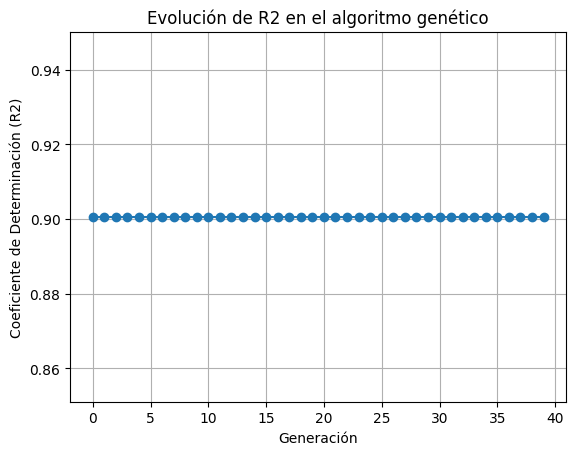

Mejor individuo (selección de características): [1, 1, 0]
Características seleccionadas: [0, 1]
Coeficiente de determinación (R2) final: 0.9005833101920356


In [75]:
import random
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

# Asegúrate de que X e y están definidos
X = df[['TV', 'Radio', 'Newspaper']].values  # Variables predictoras
y = df['Sales'].values  # Variable objetivo

# Dividir los datos en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir el problema de optimización (minimizar el error cuadrático medio)
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))  # Minimizar el MSE
creator.create("Individual", list, fitness=creator.FitnessMin)

# Función de creación de un individuo (selección de características)
def create_individual():
    return [random.randint(0, 1) for _ in range(X.shape[1])]  # 0 o 1 para seleccionar/descartar características

# Función de evaluación (aptitud) que usa la regresión lineal
def evaluate(individual):
    selected_features = [i for i, x in enumerate(individual) if x == 1]  # Selección de características
    
    if len(selected_features) == 0:
        return float('inf'),  # Si no se seleccionan características, el MSE es infinito
    
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]
    
    # Crear el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X_train_selected, y_train)
    
    # Evaluar el modelo
    y_pred = model.predict(X_test_selected)
    mse = mean_squared_error(y_test, y_pred)
    
    # Devolver el MSE para la aptitud (devuelvo un único valor)
    return mse,  # Es un tuple, pero solo contiene un valor, el MSE

# Crear la caja de herramientas DEAP
toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", tools.cxOnePoint)  # Cruzamiento de un punto
toolbox.register("mutate", tools.mutFlipBit, indpb=0.2)  # Mutación: cambiar 0 por 1 o viceversa
toolbox.register("select", tools.selTournament, tournsize=3)  # Selección por torneo
toolbox.register("evaluate", evaluate)

# Inicializar la población
population = toolbox.population(n=50)  # Tamaño de la población

# Parámetros del algoritmo genético
cxpb = 0.7  # Probabilidad de cruzamiento
mutpb = 0.2  # Probabilidad de mutación
ngen = 40    # Número de generaciones

# Lista para guardar los R2 de cada generación
r2_values = []

# Ejecutar el algoritmo genético y almacenar R2 de cada generación
for gen in range(ngen):
    print(f"Generación {gen}")
    algorithms.eaSimple(population, toolbox, cxpb=cxpb, mutpb=mutpb, ngen=1, verbose=False)
    
    # Obtener el mejor individuo de esta generación
    best_individual = tools.selBest(population, 1)[0]
    
    # Evaluar el modelo con el mejor individuo (selección de características)
    mse, = evaluate(best_individual)  # SOLO desempaquetamos el MSE

    # Calcular el R2 por separado
    selected_features = [i for i, x in enumerate(best_individual) if x == 1]
    X_train_selected = X_train[:, selected_features]
    X_test_selected = X_test[:, selected_features]
    
    model = LinearRegression()
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    r2 = r2_score(y_test, y_pred)  # Calcular R2 por separado
    r2_values.append(r2)  # Guardamos el R2 para graficar

# Graficar la evolución del R2
plt.plot(range(ngen), r2_values, marker='o')
plt.xlabel('Generación')
plt.ylabel('Coeficiente de Determinación (R2)')
plt.title('Evolución de R2 en el algoritmo genético')
plt.grid(True)
plt.show()

# Obtener el mejor individuo al final del algoritmo genético
best_individual = tools.selBest(population, 1)[0]
print("Mejor individuo (selección de características):", best_individual)

# Seleccionar las características según el mejor individuo
selected_features = [i for i, x in enumerate(best_individual) if x == 1]
print("Características seleccionadas:", selected_features)

# Evaluar el modelo con las características seleccionadas
X_train_selected = X_train[:, selected_features]
X_test_selected = X_test[:, selected_features]

# Entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)

# Evaluar el modelo con R2
final_r2 = r2_score(y_test, y_pred)
print("Coeficiente de determinación (R2) final:", final_r2)



#### Después de ejecutar el algoritmo genético, el modelo seleccionó las mejores características para predecir las ventas, quedándose solo con TV y Radio, y descartando Newspaper. El rendimiento del modelo es bastante bueno, ya que al final de las 40 generaciones, alcanzó un coeficiente de determinación (R²) de 0.9005. Esto significa que el modelo explica el 90.05% de la variabilidad en las ventas, lo cual es un resultado excelente. En resumen, el algoritmo genético no solo optimizó la selección de variables, sino que también mejoró considerablemente el desempeño del modelo, lo que muestra que solo con las dos características más relevantes se puede hacer una predicción bastante precisa de las ventas.